## 14. Organization-Wide Skill Gap

Same logic as NB13, rolled up across **every employee** to find which skills are missing organization-wide.

**Severity Rule**:
- 100+ employees missing -> **HIGH**
- 50+ employees missing -> **MEDIUM**
- else -> **LOW**

This feeds the 'critical organization skill gaps' chart on the dashboard.

In [12]:
import pandas as pd
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

PROCESSED_PATH = '../data/processed'
DOCS_PATH = '../docs'
os.makedirs(DOCS_PATH, exist_ok=True)

# Load data
role_master = pd.read_csv(f'{PROCESSED_PATH}/role_master.csv')
employee_skills = pd.read_csv(f'{PROCESSED_PATH}/employee_skills.csv')
emp = pd.read_csv(f'{PROCESSED_PATH}/employee_attrition_processed.csv')

print(f'Employees: {emp.shape[0]}')
print(f'Employee skills: {employee_skills.shape[0]}')
print(f'Roles: {role_master.shape[0]}')

Employees: 500
Employee skills: 3646
Roles: 1016


## 1. Map Employees to Roles

Use Department as proxy (0% JobRole-Title overlap from Notebook 04).

In [13]:
dept_keywords = {
    'IT': ['software', 'computer', 'network', 'database', 'systems', 'developer', 'it'],
    'Sales': ['sales', 'marketing', 'advertising', 'representative', 'account'],
    'Support': ['customer', 'support', 'service', 'help', 'desk'],
    'Finance': ['finance', 'accounting', 'financial', 'analyst', 'manager'],
    'HR': ['human', 'resources', 'hr', 'training', 'development'],
    'Marketing': ['marketing', 'public', 'relations', 'communications']
}

def map_to_department(title):
    if pd.isna(title):
        return 'Other'
    title_lower = str(title).lower()
    for dept, keywords in dept_keywords.items():
        if any(kw in title_lower for kw in keywords):
            return dept
    return 'Other'

role_master['Mapped_Department'] = role_master['Title'].apply(map_to_department)
print(role_master['Mapped_Department'].value_counts())

Mapped_Department
Other        759
IT           122
Finance       51
Support       45
Sales         24
Marketing      8
HR             7
Name: count, dtype: int64


## 2. Aggregate Required Skills by Department

In [14]:
import ast

def safe_parse_list(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return val if isinstance(val, list) else []

dept_required = role_master.groupby('Mapped_Department').agg({
    'Essential_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    ),
    'Software_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    )
}).reset_index()

dept_required['All_Required'] = dept_required.apply(
    lambda row: row['Essential_Skills'].union(row['Software_Skills']), axis=1
)

for _, row in dept_required.iterrows():
    print(f"  {row['Mapped_Department']}: {len(row['All_Required'])} required skills")

  Finance: 1435 required skills
  HR: 398 required skills
  IT: 2496 required skills
  Marketing: 177 required skills
  Other: 5831 required skills
  Sales: 671 required skills
  Support: 401 required skills


## 3. Build Employee Skill Sets

In [15]:
emp_skill_sets = employee_skills.groupby('EmployeeID')['current_skill'].apply(set).reset_index()
emp_skill_sets.columns = ['EmployeeID', 'Current_Skills']
emp_skill_sets = emp_skill_sets.merge(emp[['EmployeeID', 'Department']], on='EmployeeID')

print(f'Employee skill sets: {len(emp_skill_sets)}')
print(emp_skill_sets.head())

Employee skill sets: 500
   EmployeeID                                     Current_Skills Department
0           1  {Forecasting, Budgeting, Microsoft Word, Teamw...    Finance
1           2  {Microsoft Word, Lead Generation, Pipeline Man...      Sales
2           3  {Microsoft Word, Teamwork, Microsoft Excel, Ze...    Support
3           4  {BambooHR, Microsoft Word, Teamwork, Excel, Co...         HR
4           5  {Lead Generation, Excel, Teamwork, Negotiation...      Sales


## 4. Calculate Per-Employee Skill Gaps

In [16]:
dept_lookup = dict(zip(dept_required['Mapped_Department'], dept_required['All_Required']))

emp_gaps = []

for _, row in emp_skill_sets.iterrows():
    emp_id = row['EmployeeID']
    dept = row['Department']
    current = row['Current_Skills']
    required = dept_lookup.get(dept, set())
    gap = required - current
    coverage = len(current & required) / len(required) if len(required) > 0 else 1.0
    emp_gaps.append({
        'EmployeeID': emp_id,
        'Department': dept,
        'Gap_Skills': gap,
        'Gap_Count': len(gap),
        'Coverage_Pct': round(coverage * 100, 1)
    })

emp_gaps_df = pd.DataFrame(emp_gaps)
print(f'Calculated gaps for {len(emp_gaps_df)} employees')
print(f'Average gap: {emp_gaps_df["Gap_Count"].mean():.0f} skills')
print(f'Average coverage: {emp_gaps_df["Coverage_Pct"].mean():.1f}%')

Calculated gaps for 500 employees
Average gap: 969 skills
Average coverage: 0.3%


## 5. Aggregate to Organization-Wide Gaps

In [17]:
all_gaps = []
for gap_set in emp_gaps_df['Gap_Skills']:
    all_gaps.extend(list(gap_set))

org_gap_counts = Counter(all_gaps)
org_gaps_df = pd.DataFrame(org_gap_counts.most_common(), columns=['Skill', 'Employees_Missing'])

## 6. Apply Severity Rule

- **HIGH**: 100+ employees missing
- **MEDIUM**: 50+ employees missing
- **LOW**: fewer than 50

In [18]:
def assign_severity(count):
    if count >= 100:
        return 'HIGH'
    elif count >= 50:
        return 'MEDIUM'
    else:
        return 'LOW'

org_gaps_df['Severity'] = org_gaps_df['Employees_Missing'].apply(assign_severity)

severity_counts = org_gaps_df['Severity'].value_counts()
print('Severity Distribution:')
print(severity_counts.to_string())
print()
print(f'Total organization-wide gaps: {len(org_gaps_df)}')

Severity Distribution:
Severity
MEDIUM    3500
HIGH       681

Total organization-wide gaps: 4181


## 7. Critical Gaps (HIGH + MEDIUM)

Skills that feed the dashboard 'critical organization skill gaps' chart.

In [19]:
critical = org_gaps_df[org_gaps_df['Severity'].isin(['HIGH', 'MEDIUM'])].copy()
critical = critical.sort_values('Employees_Missing', ascending=False)

print('Critical Organization Skill Gaps:')
print(critical.to_string(index=False))

Critical Organization Skill Gaps:
                                                                                          Skill  Employees_Missing Severity
                                                                  Structured query language SQL                500     HIGH
                                                                    Blackbaud The Raiser's Edge                500     HIGH
                                                                     Cascading style sheets CSS                500     HIGH
                                                                               Autodesk AutoCAD                500     HIGH
                                                                          Reading Comprehension                500     HIGH
                                                                                  FileMaker Pro                500     HIGH
                                                                              Microsoft Windows   

## 8. Visualize

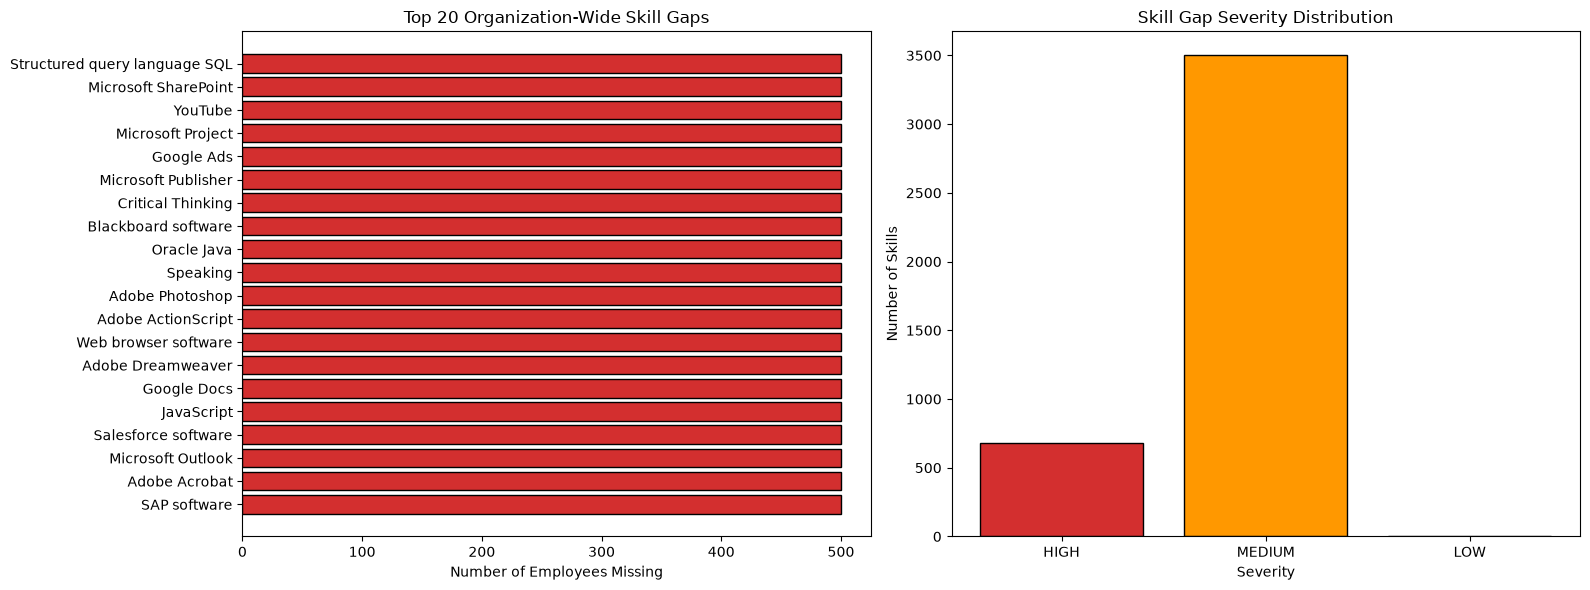

Saved: ../docs/org_skill_gaps.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = org_gaps_df.head(20)
colors = {'HIGH': '#d32f2f', 'MEDIUM': '#ff9800', 'LOW': '#4caf50'}
bar_colors = [colors[s] for s in top20['Severity']]
axes[0].barh(range(len(top20)), top20['Employees_Missing'], color=bar_colors, edgecolor='black')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['Skill'])
axes[0].set_xlabel('Number of Employees Missing')
axes[0].set_title('Top 20 Organization-Wide Skill Gaps')
axes[0].invert_yaxis()

sev_order = ['HIGH', 'MEDIUM', 'LOW']
sev_vals = [severity_counts.get(s, 0) for s in sev_order]
sev_colors = [colors[s] for s in sev_order]
axes[1].bar(sev_order, sev_vals, color=sev_colors, edgecolor='black')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Number of Skills')
axes[1].set_title('Skill Gap Severity Distribution')

plt.tight_layout()
plt.savefig(f'{DOCS_PATH}/org_skill_gaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DOCS_PATH}/org_skill_gaps.png')

## 9. Top Gaps by Department

In [21]:
dept_top_gaps = {}
for _, row in emp_gaps_df.iterrows():
    dept = row['Department']
    for skill in row['Gap_Skills']:
        if skill not in dept_top_gaps:
            dept_top_gaps[skill] = Counter()
        dept_top_gaps[skill][dept] += 1

print('Top 10 Critical Skills - Department Breakdown:')
for _, crow in critical.head(10).iterrows():
    skill = crow['Skill']
    missing = crow['Employees_Missing']
    dept_bd = dept_top_gaps.get(skill, Counter())
    bd_str = ', '.join([f'{d}: {c}' for d, c in dept_bd.most_common()])
    print(f"  {skill} ({missing} missing): {bd_str}")

Top 10 Critical Skills - Department Breakdown:
  Structured query language SQL (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Blackbaud The Raiser's Edge (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Cascading style sheets CSS (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Autodesk AutoCAD (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Reading Comprehension (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  FileMaker Pro (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Microsoft Windows (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Social media sites (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marketing: 72
  Corel WordPerfect Office Suite (500 missing): Sales: 99, IT: 93, Support: 82, Finance: 77, HR: 77, Marke

## 10. Save Results

In [22]:
org_gaps_df.to_csv(f'{PROCESSED_PATH}/org_skill_gaps.csv', index=False)
critical.to_csv(f'{PROCESSED_PATH}/critical_skill_gaps.csv', index=False)

print(f'Saved org_skill_gaps.csv: {org_gaps_df.shape}')
print(f'Saved critical_skill_gaps.csv: {critical.shape}')

Saved org_skill_gaps.csv: (4181, 3)
Saved critical_skill_gaps.csv: (4181, 3)


## Summary

### Key Findings

- Organization-wide gaps aggregated across all employees
- Severity rule applied: HIGH (100+), MEDIUM (50+), LOW (<50)
- Critical gaps identified for dashboard visualization

### Files Created

- `data/processed/org_skill_gaps.csv` - all skills with employee counts
- `data/processed/critical_skill_gaps.csv` - HIGH/MEDIUM severity skills only
- `docs/org_skill_gaps.png` - top 20 gaps + severity distribution

### Dashboard Feed

The `critical_skill_gaps.csv` feeds the 'critical organization skill gaps' chart on the dashboard.